<a href="https://colab.research.google.com/github/jealsab/deep-learning-lab-mnist/blob/main/deep-learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from torchvision import datasets, transforms
import torch
transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,))
])
mnist_train = datasets.MNIST(root='data', train=True, download=True, transform=
transform)
mnist_test = datasets.MNIST(root='data', train=False, download=True, transform=
transform)
mnist_train, mnist_val = torch.utils.data.random_split(mnist_train, [50000,
10000])

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 18.0MB/s]


In [2]:
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader


In [3]:
BATCH_SIZE = 512
train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(mnist_val,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(mnist_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(mnist_train)} | Val: {len(mnist_val)} | Test: {len(mnist_test)}")

Train: 50000 | Val: 10000 | Test: 10000


Image shape : torch.Size([1, 28, 28])
Min value   : -1.0000
Max value   : 1.0000
Mean value  : -0.7590
Label       : 0

Pixel values (28x28):
tensor([[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -

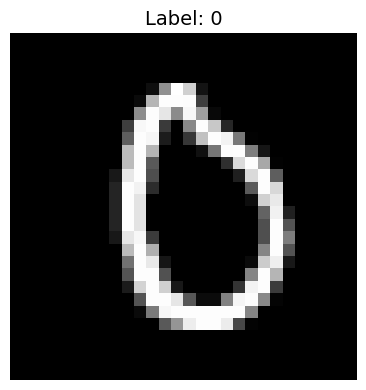

In [4]:
sample_image, sample_label = mnist_train[0]

print(f"Image shape : {sample_image.shape}")
print(f"Min value   : {sample_image.min():.4f}")
print(f"Max value   : {sample_image.max():.4f}")
print(f"Mean value  : {sample_image.mean():.4f}")
print(f"Label       : {sample_label}")
print(f"\nPixel values (28x28):\n{sample_image[0]}")

plt.figure(figsize=(4, 4))
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Label: {sample_label}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
class MLP(nn.Module):
    def __init__(self, hidden_size):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for h in [16, 32, 64]:
    print(f"Hidden size {h:2d}: {count_parameters(MLP(h)):,} parameters")

Hidden size 16: 13,002 parameters
Hidden size 32: 26,506 parameters
Hidden size 64: 55,050 parameters


In [ ]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, dim=1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    return total_loss / len(loader), 100.0 * correct / total

In [ ]:
HIDDEN_SIZES  = [16, 32, 64]
NUM_EPOCHS    = 20
LEARNING_RATE = 1e-3
results       = {}

for hidden_size in HIDDEN_SIZES:
    print(f"\n{'='*50}")
    print(f"  hidden_size = {hidden_size}")
    print(f"{'='*50}")

    model     = MLP(hidden_size=hidden_size)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_losses, val_losses = [], []

    for epoch in range(NUM_EPOCHS):
        train_loss        = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc = evaluate(model, val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | "
                  f"Val Acc: {val_acc:.2f}%")

    test_loss, test_acc = evaluate(model, test_loader)
    print(f"\n  Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

    results[hidden_size] = {
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'test_loss':    test_loss,
        'test_acc':     test_acc,
        'num_params':   count_parameters(model)
    }


  hidden_size = 16
  Epoch  5/20 | Train Loss: 0.4397 | Val Loss: 0.4075 | Val Acc: 88.32%
  Epoch 10/20 | Train Loss: 0.3419 | Val Loss: 0.3313 | Val Acc: 90.26%
  Epoch 15/20 | Train Loss: 0.3107 | Val Loss: 0.3051 | Val Acc: 91.26%
  Epoch 20/20 | Train Loss: 0.2867 | Val Loss: 0.2842 | Val Acc: 91.76%

  Test Loss: 0.2868 | Test Accuracy: 91.88%

  hidden_size = 32
  Epoch  5/20 | Train Loss: 0.3028 | Val Loss: 0.2875 | Val Acc: 91.44%
  Epoch 10/20 | Train Loss: 0.2460 | Val Loss: 0.2419 | Val Acc: 92.81%
  Epoch 15/20 | Train Loss: 0.2011 | Val Loss: 0.2087 | Val Acc: 93.86%
  Epoch 20/20 | Train Loss: 0.1674 | Val Loss: 0.1840 | Val Acc: 94.65%

  Test Loss: 0.1787 | Test Accuracy: 94.73%

  hidden_size = 64
  Epoch  5/20 | Train Loss: 0.2497 | Val Loss: 0.2452 | Val Acc: 92.85%
  Epoch 10/20 | Train Loss: 0.1676 | Val Loss: 0.1768 | Val Acc: 94.61%
  Epoch 15/20 | Train Loss: 0.1233 | Val Loss: 0.1401 | Val Acc: 95.81%
  Epoch 20/20 | Train Loss: 0.0949 | Val Loss: 0.1366 | Va

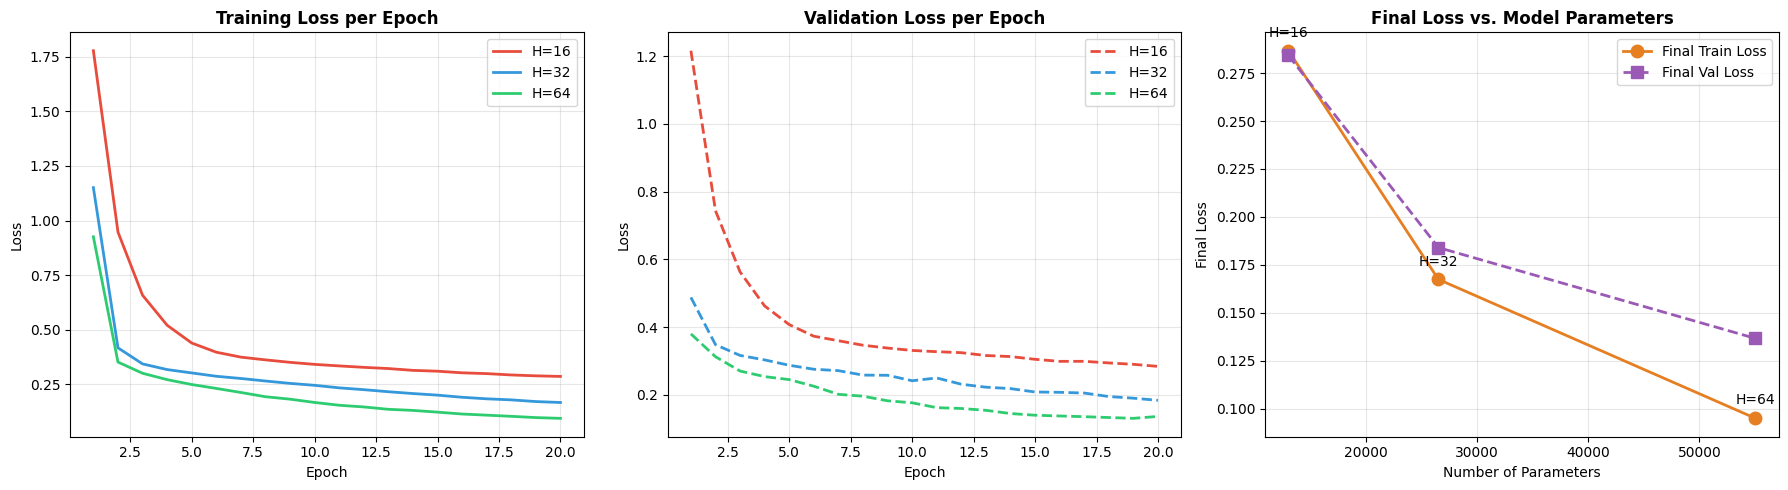


  Hidden   |    Params    | Test Loss  |  Test Acc 
    16     |    13,002    |   0.2868   |   91.88  %
    32     |    26,506    |   0.1787   |   94.73  %
    64     |    55,050    |   0.1277   |   95.98  %


In [ ]:
colors = {16: '#e74c3c', 32: '#3498db', 64: '#2ecc71'}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training loss curves
ax = axes[0]
for h in HIDDEN_SIZES:
    ax.plot(range(1, NUM_EPOCHS + 1), results[h]['train_losses'],
            label=f'H={h}', color=colors[h], linewidth=2)
ax.set_title('Training Loss per Epoch', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# Validation loss curves
ax = axes[1]
for h in HIDDEN_SIZES:
    ax.plot(range(1, NUM_EPOCHS + 1), results[h]['val_losses'],
            label=f'H={h}', color=colors[h], linewidth=2, linestyle='--')
ax.set_title('Validation Loss per Epoch', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# Final loss vs. number of parameters
ax = axes[2]
param_counts = [results[h]['num_params']       for h in HIDDEN_SIZES]
final_train  = [results[h]['train_losses'][-1] for h in HIDDEN_SIZES]
final_val    = [results[h]['val_losses'][-1]   for h in HIDDEN_SIZES]

ax.plot(param_counts, final_train, 'o-',  label='Final Train Loss', color='#e67e22', linewidth=2, markersize=9)
ax.plot(param_counts, final_val,   's--', label='Final Val Loss',   color='#9b59b6', linewidth=2, markersize=9)

for h, pc, ft in zip(HIDDEN_SIZES, param_counts, final_train):
    ax.annotate(f'H={h}', (pc, ft), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)

ax.set_title('Final Loss vs. Model Parameters', fontweight='bold')
ax.set_xlabel('Number of Parameters'); ax.set_ylabel('Final Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'='*60}")
print(f"{'Hidden':^10} | {'Params':^12} | {'Test Loss':^10} | {'Test Acc':^10}")
print('='*60)
for h in HIDDEN_SIZES:
    r = results[h]
    print(f"{h:^10} | {r['num_params']:^12,} | {r['test_loss']:^10.4f} | {r['test_acc']:^9.2f}%")
print('='*60)

# 3.1.2a Implement CNN


In [ ]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Conv 1: 32 filters
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv 2: 64 filters
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Global Average Pooling → 1x1
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

Initiate CNN model

In [ ]:
model = CNN()

import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Training

In [ ]:
for epoch in range(20):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        # MNIST is (B,1,28,28) → CNN expects same shape (no flatten!)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.9961
Epoch 2, Loss: 1.5063
Epoch 3, Loss: 1.3131
Epoch 4, Loss: 1.1390
Epoch 5, Loss: 0.9950
Epoch 6, Loss: 0.8749
Epoch 7, Loss: 0.7777
Epoch 8, Loss: 0.6953
Epoch 9, Loss: 0.6190
Epoch 10, Loss: 0.5546
Epoch 11, Loss: 0.5027
Epoch 12, Loss: 0.4609
Epoch 13, Loss: 0.4324
Epoch 14, Loss: 0.4067
Epoch 15, Loss: 0.3878
Epoch 16, Loss: 0.3620
Epoch 17, Loss: 0.3453
Epoch 18, Loss: 0.3269
Epoch 19, Loss: 0.3152
Epoch 20, Loss: 0.3031


Testing

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 91.58


3.1.2b

In [ ]:
train_losses = []
val_losses = []

In [ ]:
for epoch in range(20):
    # ---- TRAIN ----
    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_losses.append(running_train_loss / len(train_loader))

    # ---- VALIDATION ----
    model.eval()
    running_val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    val_losses.append(running_val_loss / len(val_loader))

    print(f"Epoch {epoch+1}: Train Loss {train_losses[-1]:.4f}, Val Loss {val_losses[-1]:.4f}")

Epoch 1: Train Loss 0.2936, Val Loss 0.3022
Epoch 2: Train Loss 0.2773, Val Loss 0.2978
Epoch 3: Train Loss 0.2674, Val Loss 0.2750
Epoch 4: Train Loss 0.2582, Val Loss 0.2636
Epoch 5: Train Loss 0.2486, Val Loss 0.2561
Epoch 6: Train Loss 0.2385, Val Loss 0.2672
Epoch 7: Train Loss 0.2326, Val Loss 0.2439
Epoch 8: Train Loss 0.2261, Val Loss 0.2600
Epoch 9: Train Loss 0.2166, Val Loss 0.2336
Epoch 10: Train Loss 0.2125, Val Loss 0.2311
Epoch 11: Train Loss 0.2075, Val Loss 0.2169
Epoch 12: Train Loss 0.2003, Val Loss 0.2187
Epoch 13: Train Loss 0.1963, Val Loss 0.2199
Epoch 14: Train Loss 0.1930, Val Loss 0.2101
Epoch 15: Train Loss 0.1855, Val Loss 0.2018
Epoch 16: Train Loss 0.1805, Val Loss 0.2209
Epoch 17: Train Loss 0.1768, Val Loss 0.1893
Epoch 18: Train Loss 0.1769, Val Loss 0.1978
Epoch 19: Train Loss 0.1783, Val Loss 0.1901
Epoch 20: Train Loss 0.1655, Val Loss 0.1925


In [ ]:
for name, param in model.named_parameters():
    print(name, param.numel())

features.0.weight 288
features.0.bias 32
features.3.weight 18432
features.3.bias 64
classifier.0.weight 4096
classifier.0.bias 64
classifier.2.weight 640
classifier.2.bias 10


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 23626


#3.1.3a CAN implementation

In [5]:
import torch
import torch.nn as nn

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # ---------------- ENCODER ----------------
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28 → 14
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 14 → 7
            nn.ReLU()
        )

        # ---------------- DECODER ----------------
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2,
                               padding=1, output_padding=1),      # 7 → 14
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2,
                               padding=1, output_padding=1),      # 14 → 28
            nn.Tanh()  # because pixel values in [0,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

Initiate the model

In [6]:
model = ConvAutoencoder()

import torch.optim as optim
import torch.nn as nn

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Training

In [7]:
for epoch in range(20):
    model.train()
    total_loss = 0

    for images, _ in train_loader:  # labels NOT needed
        outputs = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.1782
Epoch 2, Loss: 0.0119
Epoch 3, Loss: 0.0064
Epoch 4, Loss: 0.0048
Epoch 5, Loss: 0.0041
Epoch 6, Loss: 0.0036
Epoch 7, Loss: 0.0032
Epoch 8, Loss: 0.0029
Epoch 9, Loss: 0.0027
Epoch 10, Loss: 0.0025
Epoch 11, Loss: 0.0024
Epoch 12, Loss: 0.0023
Epoch 13, Loss: 0.0021
Epoch 14, Loss: 0.0021
Epoch 15, Loss: 0.0020
Epoch 16, Loss: 0.0019
Epoch 17, Loss: 0.0018
Epoch 18, Loss: 0.0017
Epoch 19, Loss: 0.0017
Epoch 20, Loss: 0.0016


Testing

In [8]:
model.eval()

test_loss = 0

with torch.no_grad():
    for images, _ in test_loader:
        outputs = model(images)
        loss = criterion(outputs, images)
        test_loss += loss.item()

print("Test Reconstruction Loss:", test_loss/len(test_loader))

Test Reconstruction Loss: 0.0015902650193311274


3.1.3b

In [9]:
import matplotlib.pyplot as plt
import torch

model.eval()

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Tanh()
  )
)

In [10]:
images, _ = next(iter(test_loader))

images = images[:10]

In [11]:
with torch.no_grad():
    reconstructed = model(images)

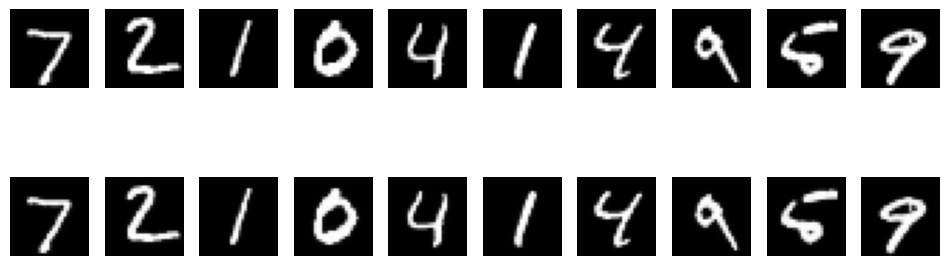

In [12]:
plt.figure(figsize=(12, 4))

for i in range(10):
    # original
    plt.subplot(2, 10, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

    # reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()